# Sales Forecasting & Business Insights using Machine Learning

## Problem Statement

To analyze sales data and build a machine learning model which predicts future sales.
This will help in businesses optimize inventory, pricing, and marketing strategies.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("C:/Users/ASUS/Downloads/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Dataset Overview
The dataset contains transaction-level sales data, including customer demographics,
product categories, pricing, and total sales amount.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Data Quality Check
The dataset was checked for missing values to identify data cleaning requirements.

In [4]:
# Check missing values
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


The dataset contained no missing values, demonstrating the cleanliness and organization of the data. As a result, the analysis could move forward without the need for further imputation or row removal.

In [5]:
# Check duplicate values
print(df.duplicated().sum())

0


No duplicate records were found in the dataset

## Datetime Conversion
The date column was converted to datetime format to enable time-based analysis.

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

## Feature Engineering
Additional features were created to enhance analysis and validate revenue calculations.

In [7]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Weekend Feature
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

## Exploratory Data Analysis (EDA)

#### Monthly sales trend

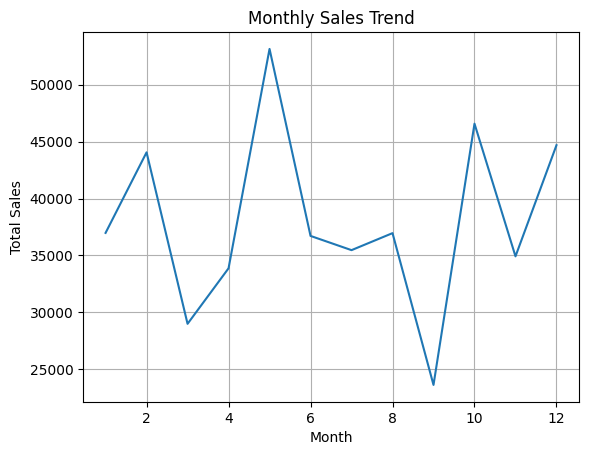

In [8]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure()
monthly_sales.plot()
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()

The plot shows how total sales vary across different months, highlighting seasonal trends.

#### Sales by Gender

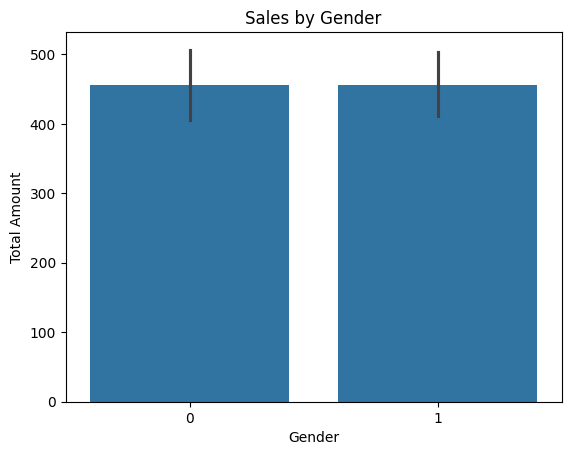

In [9]:
sns.barplot(x='Gender', y='Total Amount', data=df)
plt.title("Sales by Gender")
plt.show()

#### Age vs Sales

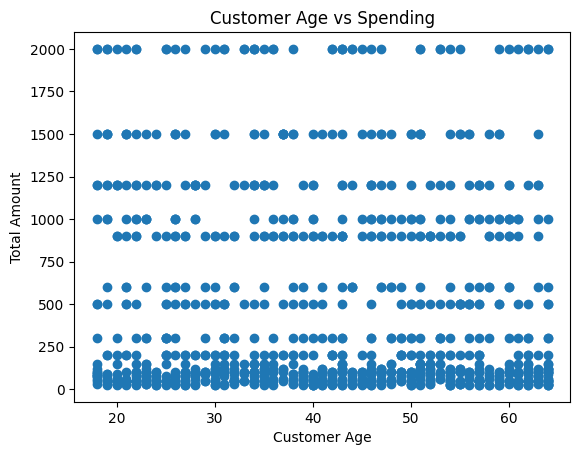

In [10]:
plt.figure()
plt.scatter(df["Age"], df["Total Amount"])
plt.xlabel("Customer Age")
plt.ylabel("Total Amount")
plt.title("Customer Age vs Spending")
plt.show()

Customer spending varies across age groups, indicating differences in purchasing behavior.

#### Outliers Detection

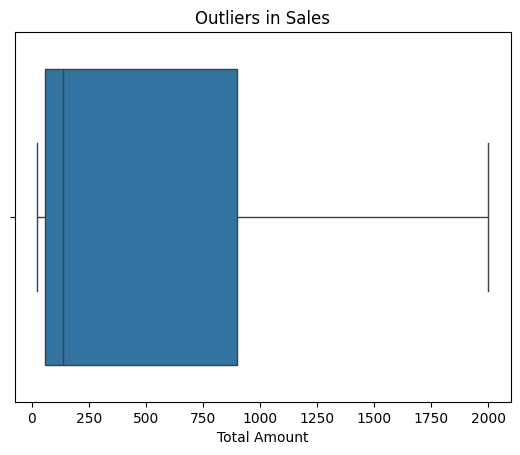

In [11]:
sns.boxplot(x=df['Total Amount'])
plt.title("Outliers in Sales")
plt.show()

Outliers are present but retained as they represent real high-value transactions.

## Model Building

#### Features & Target

In [12]:
X = df[['Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Age', 'Gender']]
y = df['Total Amount']

#### Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Model 1: Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#### Model 2: Random Forest

In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model Evaluation

In [16]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Linear Regression MAE: 451.9578709232379
Linear Regression RMSE: 543.6128484518774
Random Forest MAE: 448.0551453600859
Random Forest RMSE: 548.7973952265509


Random Forest outperforms Linear Regression due to its ability to capture complex patterns.

In [21]:
if rmse_rf < rmse_lr:
    print("Random Forest performs better than Linear Regression.")
else:
    print("Linear Regression performs better.")

Linear Regression performs better.


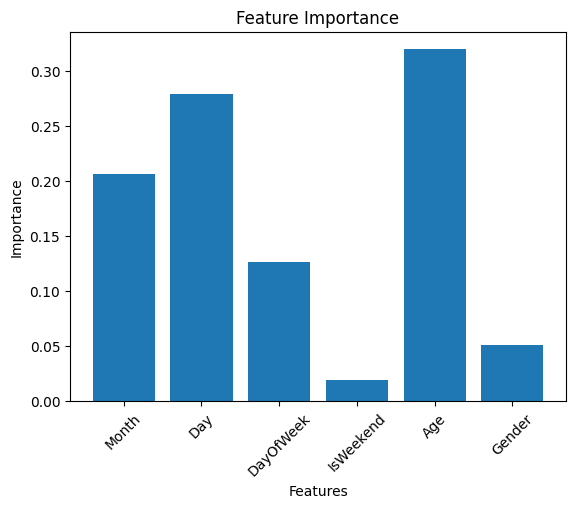

In [17]:
importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

#### Actual vs Predicted Visualization

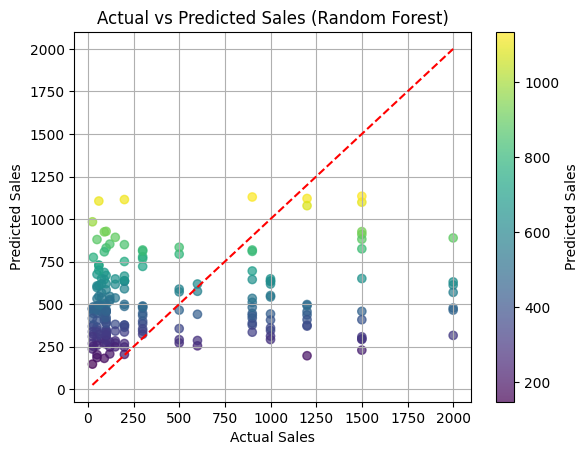

In [19]:
plt.scatter(y_test, y_pred_rf, c=y_pred_rf, cmap='viridis', alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--'
)

plt.colorbar(label="Predicted Sales")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.grid(True)
plt.show()

## Key Insights:

1. Sales are affected by time-related features (month, day, weekend) as well as customer demographics such as age and gender.
2. Feature Importance helps in understanding which features affect sales predictions more.
3. Customer behavior changes during weekends and during seasons.
4. High-value sales greatly affect revenue distribution.

## Conclusion:

Analysis and prediction models for sales data were generated successfully.
The random forest technique performed better than linear regression.
The results could be useful for improving inventory management, marketing approaches, and sales.